Task - 1: Implementation of MCP Neurons:

In [5]:
# MCP AND Function
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]   # sum of inputs

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# MCP OR Function
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Testing
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]

print("AND Output:", MCP_Neurons_AND(X1, X2, T=2))
print("OR Output:", MCP_Neurons_OR(X1, X2, T=1))


AND Output: [0, 0, 0, 1]
OR Output: [0, 1, 1, 1]


Question -
1 List out all the limitations of MCP - Neurons.

Limitations of MCP Neuron are :

   i.It cannot learn from data

  ii.Uses fixed rules (no training)

  iii.Can only solve simple problems (AND, OR)

  iv.Cannot solve XOR problem

  v.Not useful for complex real-world data






Q2: Can MCP solve XOR?

Answer:Because XOR is not linearly separable

  A single MCP neuron is not enough

  We need multiple neurons (layers)

> Add blockquote



Task 2: Perceptron (0 vs 1 MNIST)

1. Load Dataset

Upload your CSV in Colab first.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("/content/mnist_0_and_1.csv")

# Split features and labels
X = df.drop(columns=["label"]).values
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12665, 784)
y shape: (12665,)


Visualize Data

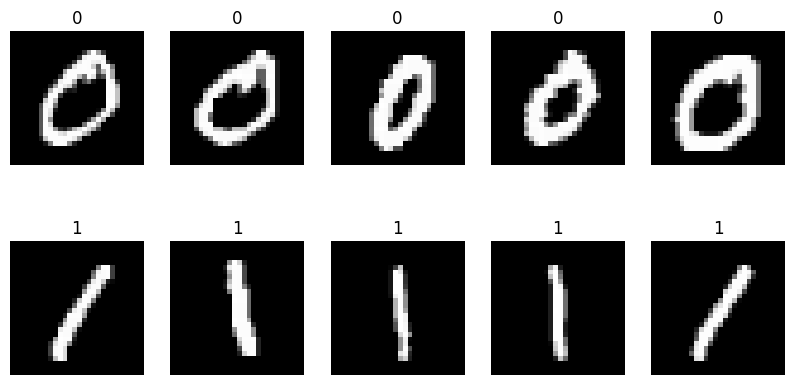

In [7]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("0")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("1")
    axes[1, i].axis("off")

plt.show()

Initialize Weights

In [8]:
weights = np.zeros(X.shape[1])  # 784 features
bias = 0
learning_rate = 0.1
epochs = 10

Decision Function

In [9]:
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    return np.where(z >= 0, 1, 0)

Train Perceptron

In [10]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=10):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0

            # Update if wrong
            if y_pred != y[i]:
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)
            else:
                correct += 1

        accuracy = correct / len(X)
        print(f"Epoch {epoch+1}, Accuracy: {accuracy:.4f}")

    return weights, bias, accuracy

Train Model

In [11]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Epoch 1, Accuracy: 0.9967
Epoch 2, Accuracy: 0.9982
Epoch 3, Accuracy: 0.9987
Epoch 4, Accuracy: 0.9987
Epoch 5, Accuracy: 0.9990
Epoch 6, Accuracy: 0.9993
Epoch 7, Accuracy: 0.9998
Epoch 8, Accuracy: 0.9995
Epoch 9, Accuracy: 0.9989
Epoch 10, Accuracy: 0.9992
Final Accuracy: 0.9992104224240032


Misclassified Images

Final Accuracy: 0.9992104224240032


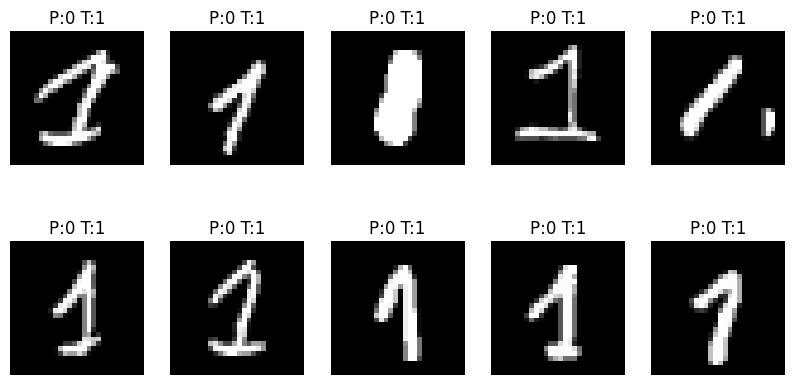

In [12]:
# Predictions
z = np.dot(X, weights) + bias
y_pred = np.where(z >= 0, 1, 0)

# Accuracy
final_accuracy = np.mean(y_pred == y)
print("Final Accuracy:", final_accuracy)

# Misclassified
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"P:{y_pred[idx]} T:{y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

Question - 1: What does the shape of X represent?

Answer: It shows number of images and features

Example: (1000, 784)

1000 = number of images

784 = pixels in each image

Question - 2: What does the shape of X represent?

Answer:It shows number of labels

One label for each image

Example: (1000,)

Question - 3: What does the weights array represent in this context?

Answer:Each weight represents importance of a pixel

Helps decide if image is 0 or 1

Question - 4: Why are we initializing the weights to zero? What effect could this
have on the training process?

Answer:Simple starting point

Model learns from scratch

No initial bias

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?

Answer: Calculates weighted sum of inputs

Used to make prediction


Question - 6: What happens when the prediction is wrong? How are the weights and
bias updated?

ANSWER: Weights are updated

Bias is updated

Model learns from mistake

Question - 7:Why is the final accuracy important, and what do you expect it to be?
Answer: Shows how well model works

Higher accuracy = better model

Expected: very high for 0 vs 1

Question - 8:What does misclassified idx store, and how is it used in this code?
Answer: Stores wrong predictions index

Used to show incorrect images

Question - 9: How do you interpret the result if the output is ”All images were
correctly classified!”?

Answer:Model made no mistakes

Accuracy is 100%

Task 3: Perceptron (3 vs 5)

In [14]:
df = pd.read_csv("/content/mnist_3_and_5.csv")

X = df.drop(columns=["label"]).values
y = df["label"].values

# Reinitialize
weights = np.zeros(X.shape[1])
bias = 0

# Train again
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy (3 vs 5):", accuracy)

Epoch 1, Accuracy: 0.0000
Epoch 2, Accuracy: 0.0000
Epoch 3, Accuracy: 0.0000
Epoch 4, Accuracy: 0.0000
Epoch 5, Accuracy: 0.0000
Epoch 6, Accuracy: 0.0000
Epoch 7, Accuracy: 0.0000
Epoch 8, Accuracy: 0.0000
Epoch 9, Accuracy: 0.0000
Epoch 10, Accuracy: 0.0000
Final Accuracy (3 vs 5): 0.0
